## Tree-based models

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import warnings

warnings.filterwarnings("ignore")

In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [4]:

MODEL_CONFIGS = {
    "tree": lambda C: DecisionTreeClassifier(
        max_depth=C, random_state=42
    ),

    "rf": lambda C: RandomForestClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),

    "extra": lambda C: ExtraTreesClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),
}
C_VALUES = [3, 5, 10]
K_VALUES = range(1, 31)

TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]
all_results = []

sorted_features = feature_importance_df.sort_values("rf_rank")["feature"].values
print(f"First feature is: {sorted_features[0]}")

for model_name, model_fn in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    for C in C_VALUES:

        print(f"  Depth/Complexity C={C}")

        for k in K_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = model_fn(C)

            for t in TOP_N_VALUES:
                summary = cross_val_eval(
                    model=model,
                    X=X_sel,
                    y=y_train,
                    n_features=k,
                    model_name=f"{model_name}_C={C}_k={k}",
                    top_n=t, scaled_features=True
                )

                summary["model_type"] = model_name
                summary["C"] = C
                summary["k"] = k
                summary["top_n"] = t

                all_results.append(summary)

final_results = pd.DataFrame(all_results)

First feature is: V191

Running model: tree
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: rf
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: extra
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10


In [5]:
final_results.sort_values(by="score", ascending=False).head(20)


,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,model_type,C,k
1711,0.6028,0.751000,0.301855,0.430626,1253.0,1093.0,4,0.013953,0.034169,0.013900,0.019760,102.506097,102.506097,extra_C=5_k=4,None,1000,extra,5,4
1967,0.6108,0.771000,0.309892,0.442092,1313.0,1073.0,6,0.014856,0.036640,0.014847,0.021130,109.920426,109.920426,extra_C=10_k=6,None,1000,extra,10,6
1951,0.5980,0.739000,0.297031,0.423744,1217.0,1057.0,4,0.012145,0.029665,0.012087,0.017175,88.994382,88.994382,extra_C=10_k=4,None,1000,extra,10,4
1463,0.5924,0.725000,0.291403,0.415715,1175.0,1055.0,3,0.010922,0.026693,0.010864,0.015442,80.078087,80.078087,extra_C=3_k=3,None,1000,extra,3,3
1719,0.6028,0.751000,0.301855,0.430626,1253.0,1053.0,5,0.013517,0.033053,0.013459,0.019129,99.158963,99.158963,extra_C=5_k=5,None,1000,extra,5,5
1983,0.6184,0.790000,0.317524,0.452982,1370.0,1050.0,8,0.013649,0.034095,0.013708,0.019553,102.286363,102.286363,extra_C=10_k=8,None,1000,extra,10,8
1703,0.5916,0.723000,0.290599,0.414568,1169.0,1049.0,3,0.012095,0.029707,0.012056,0.017150,89.120705,89.120705,extra_C=5_k=3,None,1000,extra,5,3
1479,0.6020,0.749000,0.301050,0.429478,1247.0,1047.0,5,0.013248,0.032481,0.013201,0.018771,97.442291,97.442291,extra_C=3_k=5,None,1000,extra,3,5
1743,0.6180,0.789000,0.317120,0.452406,1367.0,1047.0,8,0.012349,0.031105,0.012444,0.017775,93.313986,93.313986,extra_C=5_k=8,None,1000,extra,5,8
1959,0.6016,0.748000,0.300652,0.428908,1244.0,1044.0,5,0.016682,0.040866,0.016637,0.023647,122.596900,122.596900,extra_C=10_k=5,None,1000,extra,10,5


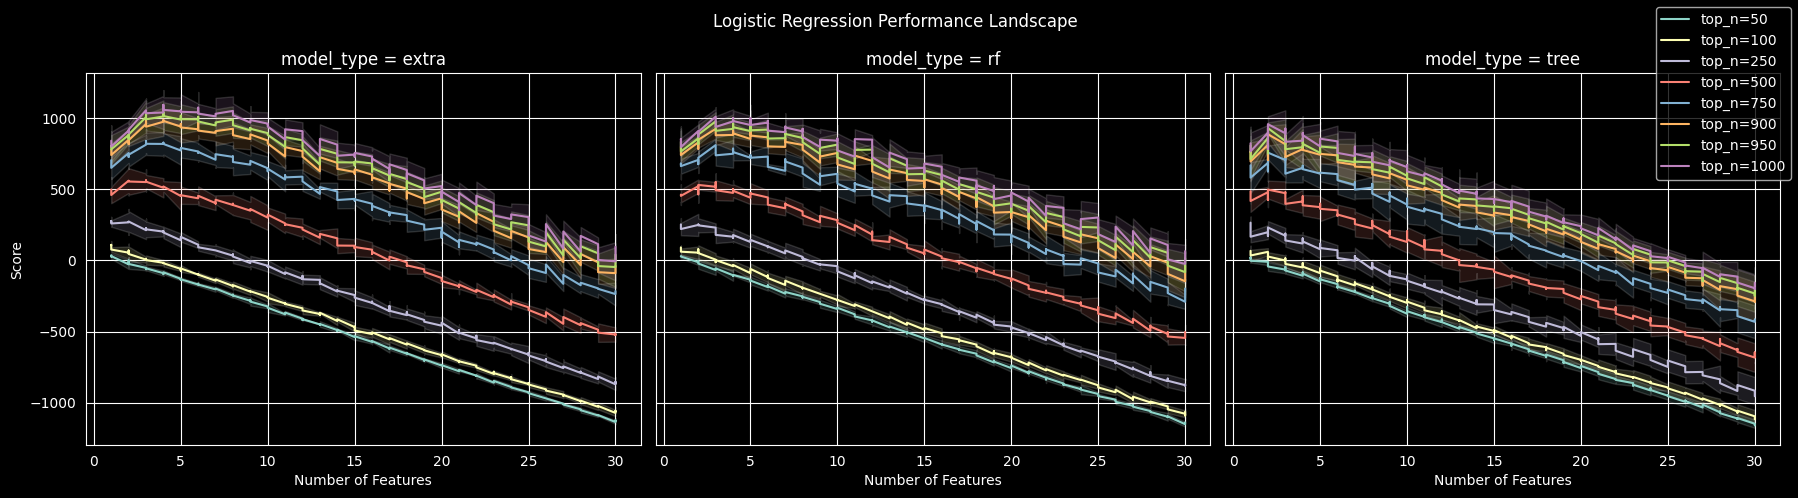

In [6]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)